## Get started
This tutorial will show you how asynctorch can be used. Make sure asynctorch, snnTorch and tonic have been installed! Tonic is not an automatic dependency of asynctorch because it is not required for all use cases. For CUDA support, make sure you have a working CUDA installation and the correct version of PyTorch installed.

Check our paper for more details: https://arxiv.org/abs/2408.05098

### Import packages

In [1]:
import torch
import tonic
import matplotlib.pyplot as plt
import tonic.transforms as transforms
from asynctorch.simulator.async_simulator import AsyncSimulator
from asynctorch.nn.architecture.mixed_architecture import MixedArchitecture, AsyncNetwork
from asynctorch.nn.neuron.lif_state import LIFState
from asynctorch.simulator.extensions.spike_dropout_extension import SpikeDropoutExtension
from asynctorch.simulator.spike_scheduler import RandomSpikeScheduler
from asynctorch.simulator.spike_scheduler import MomentumSpikeScheduler
from asynctorch.simulator.spike_selector import SpikeSelector
from torch.utils.data import DataLoader
from tqdm import tqdm
import torch.nn as nn
import snntorch.functional as SF
from asynctorch.utils.surrogate import ATan
from math import prod
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


### Load data
For this, tonic is used. This can take same time when it is run for the first time.

In [2]:
timestep_size = 10000
transform = transforms.ToFrame(sensor_size=tonic.datasets.NMNIST.sensor_size, time_window=timestep_size)
train_dataset = tonic.datasets.NMNIST(save_to="./data", transform=transform, train=True, first_saccade_only=True)
test_dataset = tonic.datasets.NMNIST(save_to="./data", transform=transform, train=False, first_saccade_only=True)
collate_fn = tonic.collation.PadTensors(batch_first=False)

### Define the network and parameters for simulator
We provide two network architectures. An architecture consists of just the connecting layer, so not the (spiking) activations / neurons. You can use the layers from PyTorch, like nn.Conv2d and nn.Linear. On top of that, you must also provide their input shape. 
In a later cell, these definitions will be used to construct the network. We assume here that you want a fully sequential network. For more advanced structures like residual connections, you must manually connect each layer to neurons. This will be discussed in another tutorial (to be added later). For now, after running "CNN" or "Linear", just run the "Build" cell to construct.

#### CNN

In [3]:
n_outputs = 10
input_shape = (2, 34, 34) # Shape of the input data
layer1_shape = (8, 16, 16)
layer2_shape = (16, 8, 8)
layer3_shape = (32, 4, 4)
module_per_layer = [nn.Conv2d(2, 8, kernel_size=3, stride=2, padding=0, bias=False), 
                    nn.Conv2d(8, 16, kernel_size=3, stride=2, padding=1, bias=False), 
                    nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1, bias=False),
                    nn.Linear(prod(layer3_shape), n_outputs, bias=False)]
shape_per_layer = [input_shape, layer1_shape, layer2_shape, (prod(layer3_shape), ), (n_outputs, )]
neurons_per_layer = [prod(shape) for shape in shape_per_layer[1:]]
n_neurons = sum(neurons_per_layer)

#### Linear

In [3]:
n_outputs = 10
input_shape = (2*34*34, ) # Shape of the input data, we flatten the input data in this way
layer1_shape = (64, )
layer2_shape = (64, )
layer3_shape = (64, )
module_per_layer = [nn.Linear(prod(input_shape), prod(layer1_shape), bias=False),
                    nn.Linear(prod(layer1_shape), prod(layer2_shape), bias=False),
                    nn.Linear(prod(layer2_shape), prod(layer3_shape), bias=False),
                    nn.Linear(prod(layer3_shape), n_outputs, bias=False)]
shape_per_layer = [(prod(input_shape), ), layer1_shape, layer2_shape, layer3_shape, (n_outputs, )]
neurons_per_layer = [prod(shape) for shape in shape_per_layer[1:]]
n_neurons = sum(neurons_per_layer)

In [3]:
# ── Cell: Network Architecture (Linear/MLP — برای کد inference ما) ──────────

n_outputs    = 10
input_shape  = (2*34*34, )   # flatten کردن N-MNIST: 2 polarity × 34 × 34 = 2312
layer1_shape = (128, )        # hidden layer — باید با layer_sizes[1] در YAML یکی باشد
# layer1_shape = (256, )      # اگر می‌خواهی بزرگتر

module_per_layer = [
    nn.Linear(prod(input_shape), prod(layer1_shape), bias=False),  # W1: [2312→128]
    nn.Linear(prod(layer1_shape), n_outputs, bias=False),           # W2: [128→10]
]

shape_per_layer = [
    input_shape,    # (2312,)
    layer1_shape,   # (128,)
    (n_outputs, )   # (10,)
]

neurons_per_layer = [prod(shape) for shape in shape_per_layer[1:]]
n_neurons = sum(neurons_per_layer)

print(f"input_shape     : {input_shape}   → {prod(input_shape)} neurons")
print(f"layer1_shape    : {layer1_shape}  → {prod(layer1_shape)} neurons")
print(f"output          : {n_outputs} neurons")
print(f"W1 shape        : ({prod(input_shape)}, {prod(layer1_shape)})")
print(f"W2 shape        : ({prod(layer1_shape)}, {n_outputs})")
print(f"layer_sizes YAML: [{prod(input_shape)}, {prod(layer1_shape)}, {n_outputs}]")

input_shape     : (2312,)   → 2312 neurons
layer1_shape    : (128,)  → 128 neurons
output          : 10 neurons
W1 shape        : (2312, 128)
W2 shape        : (128, 10)
layer_sizes YAML: [2312, 128, 10]


In [3]:
# 3 Hidden Layers ── Cell: Network Architecture (Linear/MLP — for our inference code) ──────────

from math import prod
import torch.nn as nn

n_outputs   = 10
input_shape = (2 * 34 * 34,)   # N-MNIST flatten: 2 polarity × 34 × 34 = 2312

# According to the paper: [64 × 3] - 10
layer1_shape = (64,)           # hidden layer 1
layer2_shape = (64,)           # hidden layer 2
layer3_shape = (64,)           # hidden layer 3

module_per_layer = [
    nn.Linear(prod(input_shape),  prod(layer1_shape), bias=False),  # W1: 2312 → 64
    nn.Linear(prod(layer1_shape), prod(layer2_shape), bias=False),  # W2: 64 → 64
    nn.Linear(prod(layer2_shape), prod(layer3_shape), bias=False),  # W3: 64 → 64
    nn.Linear(prod(layer3_shape), n_outputs,          bias=False),  # W4: 64 → 10
]

shape_per_layer = [
    input_shape,     # (2312,)
    layer1_shape,    # (64,)
    layer2_shape,    # (64,)
    layer3_shape,    # (64,)
    (n_outputs,),    # (10,)
]

neurons_per_layer = [prod(shape) for shape in shape_per_layer[1:]]
n_neurons = sum(neurons_per_layer)

print(f"input_shape     : {input_shape}   → {prod(input_shape)} neurons")
print(f"layer1_shape    : {layer1_shape}  → {prod(layer1_shape)} neurons")
print(f"layer2_shape    : {layer2_shape}  → {prod(layer2_shape)} neurons")
print(f"layer3_shape    : {layer3_shape}  → {prod(layer3_shape)} neurons")
print(f"output          : {n_outputs} neurons")

print(f"W1 shape        : ({prod(input_shape)}, {prod(layer1_shape)})")
print(f"W2 shape        : ({prod(layer1_shape)}, {prod(layer2_shape)})")
print(f"W3 shape        : ({prod(layer2_shape)}, {prod(layer3_shape)})")
print(f"W4 shape        : ({prod(layer3_shape)}, {n_outputs})")

print(
    f"layer_sizes YAML: "
    f"[{prod(input_shape)}, {prod(layer1_shape)}, {prod(layer2_shape)}, "
    f"{prod(layer3_shape)}, {n_outputs}]"
)

input_shape     : (2312,)   → 2312 neurons
layer1_shape    : (64,)  → 64 neurons
layer2_shape    : (64,)  → 64 neurons
layer3_shape    : (64,)  → 64 neurons
output          : 10 neurons
W1 shape        : (2312, 64)
W2 shape        : (64, 64)
W3 shape        : (64, 64)
W4 shape        : (64, 10)
layer_sizes YAML: [2312, 64, 64, 64, 10]


#### Build
The building process consists of first taking the network definitions from the previous cells and then using those to construct an architecture module. This will provide the logic for how to forward spikes and currents. How the neurons behave is defined in a state module, in this case LIF neurons are used. The last step is defining how spikes are selected and then combining everything into the simulator environment. Optionally, "extensions" can be provided. In this example, spike dropout will be used for regularization, but only applied to the input. Different from torch dropout, it is not directly included in the architecture, but rather added as an extension.

In [4]:
# Network architecture
async_network = AsyncNetwork.build_sequential(module_per_layer, shape_per_layer).to(device)
print(async_network)
print('Number of neurons:', n_neurons)
print('Number of parameters:', sum(p.numel() for p in async_network.parameters() if p.requires_grad))
network_module = MixedArchitecture(async_network, device)

# Neuron model
spike_grad = ATan()
state_module = LIFState(
    neurons_per_layer,
    tau_m=1000,
    membrane_threshold=0.3,
    spike_grad=spike_grad,
    device=device,
    refrac_dropout=0.8, # Probability that a neuron can spike again in the same forward pass during training, check paper for more details
)

# Spike selection
# spike_scheduler = RandomSpikeScheduler(state_module)
spike_scheduler = MomentumSpikeScheduler(state_module, lambda_=0.9) # This scheduler prioritizes neurons that have been active in the past, check paper for more details

spike_selector_module = SpikeSelector(
    network_module,
    spike_scheduler,
    forward_group_size=8, # How many spikes are processed in parallel per forward step
    device=device,
    prioritize_input=True,
    log_queue_length=True
)
# Simulator and extensions
input_dropout = SpikeDropoutExtension(p=0.25, apply_to_input=True, apply_to_network=False)
async_simulator = AsyncSimulator(state_module, spike_selector_module, forward_step_extensions=[input_dropout])

AsyncNetwork(
  (input_layer): AsyncLayer(
    (module): Linear(in_features=2312, out_features=64, bias=False)
  )
  (layers): ModuleList(
    (0-1): 2 x AsyncLayer(
      (module): Linear(in_features=64, out_features=64, bias=False)
    )
    (2): AsyncLayer(
      (module): Linear(in_features=64, out_features=10, bias=False)
    )
  )
)
Number of neurons: 202
Number of parameters: 156800


## Start training
For training, we use the standard PyTorch training loop with some snnTorch specific functions. Instead of calling a forward pass on the network, we call the forward function of the simulator. This function takes the input data and the time step, and returns the output spikes of the network. The output spikes can then be used to calculate the loss and update the weights of the network.

In [5]:

train_dataloader = DataLoader(train_dataset, batch_size=256, shuffle=True, collate_fn=collate_fn)
async_simulator.train()
n_epochs = 20
optimizer = torch.optim.Adam(async_simulator.parameters(), lr=1e-3, weight_decay=1e-5)
loss_fn = SF.ce_rate_loss()
accuracy_function = SF.accuracy_rate
losses = []
accuracies = []
for epoch in range(n_epochs):
    batch_iter = iter(train_dataloader)
    for data, targets in tqdm(batch_iter):
        data = data.to(device)
        targets = targets.to(device)
        async_simulator.reset_state() # Reset the state of the simulator (including the state of the neurons)

        # Forward pass
        ys = []
        for t in range(data.shape[0]):
            ts_data = data[t].view(data[t].shape[0], -1)
            spk_out = async_simulator(ts_data, dt=timestep_size)[:, n_neurons-n_outputs:]
            ys.append(spk_out) 
        y = torch.stack(ys)
        loss = loss_fn(y, targets)
        losses.append(loss.item())
        accuracy = accuracy_function(y, targets)
        accuracies.append(accuracy)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

100%|██████████| 235/235 [02:16<00:00,  1.72it/s]


In [6]:
# ── Save weights after training ───────────────────────────────────────────────
import numpy as np
import json
import os

save_dir = "./weights_nmnist"
os.makedirs(save_dir, exist_ok=True)

# Extract weight matrices from async_network (asynctorch stores them as nn.Linear)
# Shape from PyTorch: [out, in]  →  we save both as-is AND transposed [in, out] for Laurent
weight_list = []
for name, param in async_network.named_parameters():
    if param.requires_grad:
        w = param.detach().cpu().numpy()   # shape [out, in]
        weight_list.append(w)
        print(f"  {name}: {w.shape}")

# ── 1. .npz  (keys arr_0, arr_1, ...)  ───────────────────────────────────────
# Saved as [out, in]  — sepi_tmlr_nmnist_frame.py auto-transposes on load
npz_path = os.path.join(save_dir, "weights_nmnist_3hidden_1006_1.npz")
np.savez(npz_path, *weight_list)
print(f"Saved .npz → {npz_path}")

# ── 2. .json  (same [out, in] layout, one key per layer) ─────────────────────
json_path = os.path.join(save_dir, "weights_nmnist_1006_1.json")
json_data = {f"layer_{i}": w.tolist() for i, w in enumerate(weight_list)}
with open(json_path, "w") as f:
    json.dump(json_data, f)
print(f"Saved .json → {json_path}")

# ── 3. Laurent-format .json  ([in, out] transposed, keys layer_1, layer_2) ───
laurent_path = os.path.join(save_dir, "weights_nmnist_3hidden_1006_1_laurent.json")
laurent_data = {f"layer_{i+1}": w.T.tolist() for i, w in enumerate(weight_list)}
with open(laurent_path, "w") as f:
    json.dump(laurent_data, f)
print(f"Saved Laurent .json → {laurent_path}")

# ── 4. .pt  (PyTorch state_dict, for reloading into asynctorch) ──────────────
import torch
pt_path = os.path.join(save_dir, "weights_nmnist_3hidden_1006_1.pt")
torch.save(async_network.state_dict(), pt_path)
print(f"Saved .pt → {pt_path}")

print("\nWeight shapes summary:")
for i, w in enumerate(weight_list):
    print(f"  W{i+1}: {w.shape}  (asynctorch [out,in])  →  Laurent: {w.T.shape} ([in,out])")

  input_layer.module.weight: (64, 2312)
  layers.0.module.weight: (64, 64)
  layers.1.module.weight: (64, 64)
  layers.2.module.weight: (10, 64)
Saved .npz → ./weights_nmnist/weights_nmnist_3hidden_1006_1.npz
Saved .json → ./weights_nmnist/weights_nmnist_1006_1.json
Saved Laurent .json → ./weights_nmnist/weights_nmnist_3hidden_1006_1_laurent.json
Saved .pt → ./weights_nmnist/weights_nmnist_3hidden_1006_1.pt

Weight shapes summary:
  W1: (64, 2312)  (asynctorch [out,in])  →  Laurent: (2312, 64) ([in,out])
  W2: (64, 64)  (asynctorch [out,in])  →  Laurent: (64, 64) ([in,out])
  W3: (64, 64)  (asynctorch [out,in])  →  Laurent: (64, 64) ([in,out])
  W4: (10, 64)  (asynctorch [out,in])  →  Laurent: (64, 10) ([in,out])


In [10]:
# ── Save weights after training ───────────────────────────────────────────────
import numpy as np
import json
import os
from datetime import datetime

save_dir = "./weights_nmnist"
os.makedirs(save_dir, exist_ok=True)

# Extract weight matrices from async_network (asynctorch stores them as nn.Linear)
weight_list = []
for name, param in async_network.named_parameters():
    if param.requires_grad:
        w = param.detach().cpu().numpy()   # shape [out, in]
        weight_list.append(w)
        print(f"  {name}: {w.shape}")

# ── Build automatic filename tag ──────────────────────────────────────────────
# Architecture from weight shapes: input = W0.shape[1], then out-dims of each layer
arch = [weight_list[0].shape[1]] + [w.shape[0] for w in weight_list]   # e.g. [2312, 128, 128, 128, 10]
n_hidden = len(weight_list) - 1                                        # number of hidden layers
arch_str = "x".join(str(d) for d in arch)                              # "2312x128x128x128x10"
date_str = datetime.now().strftime("%d%m%Y")                           # e.g. "12062026"
# Read forward_group_size directly from the trained SpikeSelector object
forward_group_size = getattr(spike_selector_module, "forward_group_size", None)
if forward_group_size is None:
    # fallback: some versions store it under a different attribute name
    forward_group_size = getattr(spike_selector_module, "group_size", 128)
print(f"forward_group_size (from spike_selector_module): {forward_group_size}")

tag = f"nmnist_{n_hidden}hidden_{arch_str}_fgs{forward_group_size}_{date_str}"
# forward_group_size must already be defined in the notebook (same value used in training!)
tag = f"nmnist_{n_hidden}hidden_{arch_str}_fgs{forward_group_size}_{date_str}"
print(f"\nFilename tag: {tag}")
# → e.g. "nmnist_3hidden_2312x128x128x128x10_fgs128_12062026"

# ── 1. .npz  (keys arr_0, arr_1, ...)  ───────────────────────────────────────
npz_path = os.path.join(save_dir, f"weights_{tag}.npz")
np.savez(npz_path, *weight_list)
print(f"Saved .npz → {npz_path}")

# ── 2. .json  (same [out, in] layout, one key per layer) ─────────────────────
json_path = os.path.join(save_dir, f"weights_{tag}.json")
json_data = {f"layer_{i}": w.tolist() for i, w in enumerate(weight_list)}
with open(json_path, "w") as f:
    json.dump(json_data, f)
print(f"Saved .json → {json_path}")

# ── 3. Laurent-format .json  ([in, out] transposed, keys layer_1, layer_2) ───
laurent_path = os.path.join(save_dir, f"weights_{tag}_laurent.json")
laurent_data = {f"layer_{i+1}": w.T.tolist() for i, w in enumerate(weight_list)}
with open(laurent_path, "w") as f:
    json.dump(laurent_data, f)
print(f"Saved Laurent .json → {laurent_path}")

# ── 4. .pt  (PyTorch state_dict, for reloading into asynctorch) ──────────────
import torch
pt_path = os.path.join(save_dir, f"weights_{tag}.pt")
torch.save(async_network.state_dict(), pt_path)
print(f"Saved .pt → {pt_path}")

print("\nWeight shapes summary:")
for i, w in enumerate(weight_list):
    print(f"  W{i+1}: {w.shape}  (asynctorch [out,in])  →  Laurent: {w.T.shape} ([in,out])")

  input_layer.module.weight: (64, 2312)
  layers.0.module.weight: (64, 64)
  layers.1.module.weight: (64, 64)
  layers.2.module.weight: (10, 64)
forward_group_size (from spike_selector_module): 8

Filename tag: nmnist_3hidden_2312x64x64x64x10_fgs8_12062026
Saved .npz → ./weights_nmnist/weights_nmnist_3hidden_2312x64x64x64x10_fgs8_12062026.npz
Saved .json → ./weights_nmnist/weights_nmnist_3hidden_2312x64x64x64x10_fgs8_12062026.json
Saved Laurent .json → ./weights_nmnist/weights_nmnist_3hidden_2312x64x64x64x10_fgs8_12062026_laurent.json
Saved .pt → ./weights_nmnist/weights_nmnist_3hidden_2312x64x64x64x10_fgs8_12062026.pt

Weight shapes summary:
  W1: (64, 2312)  (asynctorch [out,in])  →  Laurent: (2312, 64) ([in,out])
  W2: (64, 64)  (asynctorch [out,in])  →  Laurent: (64, 64) ([in,out])
  W3: (64, 64)  (asynctorch [out,in])  →  Laurent: (64, 64) ([in,out])
  W4: (10, 64)  (asynctorch [out,in])  →  Laurent: (64, 10) ([in,out])


### Plot the training progress

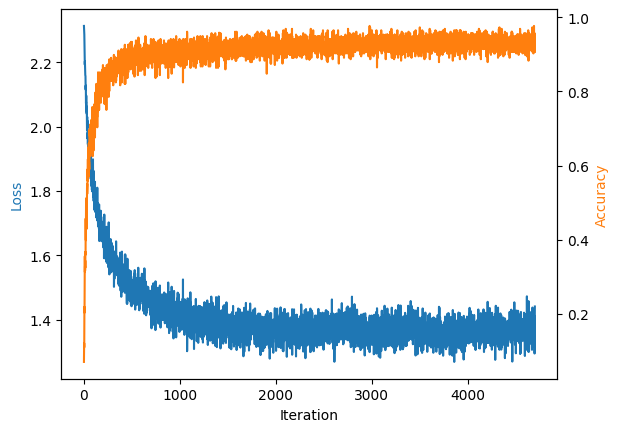

In [11]:
fig, ax1 = plt.subplots()

ax2 = ax1.twinx()
ax1.plot(losses, color='C0')
ax2.plot(accuracies, color='C1')

ax1.set_xlabel('Iteration')
ax1.set_ylabel('Loss', color='C0')
ax2.set_ylabel('Accuracy', color='C1')

plt.show()

## Test the model

In [12]:
async_simulator.eval()
test_dataloader = DataLoader(test_dataset, batch_size=128, shuffle=False, collate_fn=collate_fn)
accuracies = []
batch_sizes = []

with torch.inference_mode():
    for data, targets in tqdm(test_dataloader):
        data = data.to(device)
        targets = targets.to(device)
        async_simulator.reset_state()
        ys = []
        for t in range(data.shape[0]):
            ts_data = data[t].float().view(data[t].shape[0], -1)
            spk_out = async_simulator(ts_data, dt=timestep_size)[:, n_neurons-n_outputs:]
            ys.append(spk_out) 
        y = torch.stack(ys).sum(dim=0)
        predictions = torch.argmax(y, dim=1)
        accuracy = predictions.eq(targets).float().mean().cpu().item()
        accuracies.append(accuracy)
        batch_sizes.append(data.shape[0])

print("Test accuracy: ", sum([a*b for a, b in zip(accuracies, batch_sizes)]) / sum(batch_sizes))

100%|██████████| 79/79 [00:29<00:00,  2.70it/s]

Test accuracy:  0.9288963607594937
